# 35-Year Intercomparison of Pettitt-Derived Melt Dates
This section presents a 35-year (1988–2022) intercomparison between Pettitt-derived melt dates and other datasets using density-based scatter plots. The purpose of this analysis is to evaluate the consistency and behavior of the Pettitt-based estimates across different data sources.

The comparison is conducted on a pixel-by-pixel and year-by-year basis. Only cases where both the Pettitt-derived value and the corresponding value from another dataset are available for the same grid cell and year are included. For example, if both Pettitt MOD and ERA5 MOD exist at a given location (e.g., 60°N, 120°E) in 1988, that pair is included as a single point in the scatter plot.

The resulting plots combine scatter points with density information to clearly illustrate the distribution, concentration, and agreement between datasets over the full spatial and temporal domain.

In [1]:
import sys
import os
import platform
import importlib
import math
import glob
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import calendar
import netCDF4 as nc
import xarray as xr
from datetime import timedelta
import datetime
from dateutil.relativedelta import relativedelta
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Proj, transform
import cartopy.feature as cfeature
import matplotlib.colors as colors
import matplotlib.path as mpath
import rioxarray
import rasterio
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm
import geopandas as gpd
from shapely.geometry import Point
from scipy.stats import linregress, spearmanr

if platform.system() == 'Darwin':  # macOS
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data_2'
else:
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data_2'
sys.path.append(base_FP + '/python_modules')

# HydroAI libs
import HydroAI.Data as hData
import HydroAI.Plot as hPlot
import HydroAI.Grid as hGrid
import HydroAI.Land_Properties as hLP
importlib.reload(hData);
importlib.reload(hPlot);
importlib.reload(hGrid);
importlib.reload(hLP);

# Ignore runtime warnings
import warnings
warnings.filterwarnings("ignore")

## Define a function to generate density plots

In [2]:
def plot_density_3d_vs_3d_clusters012(
    A3, B3, mask,            # (H,W,Y)  
    cluster_map,             # (H,W)
    include_clusters=(0,1,2), # Perform only for pixels belonging to the selected clusters
    min_n=1,
    gridsize=60,
    cmap="viridis",
    bins="log",
    extent=(1, 366, 1, 366),
    x_label="In situ MOD (DOY)",
    y_label="Pettitt MOD (DOY)",
    title_prefix="",
):
    A3 = np.asarray(A3, float)
    B3 = np.asarray(B3, float)
    mask = np.asarray(mask, bool)
    cl = np.asarray(cluster_map)

    if A3.shape != B3.shape:
        raise ValueError(f"A3 and B3 must have same shape, got {A3.shape} vs {B3.shape}")
    if mask.shape != A3.shape:
        raise ValueError(f"mask must match A3 shape, got {mask.shape} vs {A3.shape}")

    H, W, Y = A3.shape
    if cl.shape != (H, W):
        raise ValueError(f"cluster_map shape mismatch: expected {(H,W)}, got {cl.shape}")

    xmin, xmax, ymin, ymax = extent

    # Only clusters 0,1,2 (No cluster 3)
    mask_hw = np.isin(cl, include_clusters)
    if not np.any(mask_hw):
        print("No pixels found in include_clusters.")
        return

    valid3 = mask & mask_hw[:, :, None]     # (H,W,Y)

    x = A3[valid3].ravel()
    y = B3[valid3].ravel()

    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]

    n = x.size
    if n < min_n:
        print(f"n={n} < {min_n}, skip")
        return

    lr = linregress(x, y)
    r2 = lr.rvalue**2 if np.isfinite(lr.rvalue) else np.nan
    r  = spearmanr(x, y)[0] if n >= 3 else np.nan

    plt.figure(figsize=(8.5, 8))
    fig=plt.gcf()
    ax=plt.gca()
    hb = plt.hexbin(
        x, y,
        gridsize=gridsize,
        extent=extent,
        cmap=cmap,
        bins=bins,
        mincnt=1
    )
    cb = plt.colorbar(hb, pad=0.02)
    cb.set_label("log10(N)" if bins == "log" else "N", fontsize=20)

    plt.plot([xmin, xmax], [ymin, ymax], "k--", lw=1)

    xx = np.array([xmin, xmax], dtype=float)
    plt.plot(xx, lr.slope * xx + lr.intercept, "k-", lw=1.5)

    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    plt.xlabel(x_label, fontsize=25)
    plt.ylabel(y_label, fontsize=25)

    #prefix = "" if not title_prefix else f"{title_prefix} — "
    #plt.title(f"{prefix}n={n:,}, slope={lr.slope:.2f}, R²={r2:.2f}, r={r:.2f}", fontsize=28, pad=20)

    plt.grid(True)  
    plt.tight_layout()
    plt.show()
    return fig, ax


## 1. Density-Based Comparison with In Situ Observations
This section presents a density-based comparison between Pettitt-derived melt dates and those derived from in situ observations. Due to the temporal availability of the in situ dataset, which extends only through 2021, the year 2022 is excluded from this analysis. Consequently, the comparison is conducted over a 34-year period.

### Load and open the Pettitt, Insitu data

In [3]:
# Open the files
TB_cluster_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Clusters/TB_cluster_map.nc'
Pettitt_MOD_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/MOD_MED/MOD_pettitt_250window_MA5_meanstd_1988_2022.nc'
Pettitt_MED_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/MOD_MED/MED_pettitt_250window_MA5_meanstd_1988_2022.nc'
In_situ_MOD_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Insitu/Insitu_MOD_1988_2021_north60.nc'
In_situ_MED_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Insitu/Insitu_MED_1988_2021_north60.nc'

with nc.Dataset(TB_cluster_path) as ds_cluster:
    lat_vals = ds_cluster.variables['lat'][:]
    lon_vals = ds_cluster.variables['lon'][:]
    TB_cluster  = ds_cluster.variables['TB_cluster'][:]   # (120, 1440)

with nc.Dataset(Pettitt_MOD_path) as ds_Pettitt_MOD:
    lat_vals = ds_Pettitt_MOD.variables['lat'][:]
    lon_vals = ds_Pettitt_MOD.variables['lon'][:]
    Pettitt_MOD  = ds_Pettitt_MOD.variables['MOD_doy'][:, :, :34]   # (120, 1440, 34) -> 1988-2021

with nc.Dataset(Pettitt_MED_path) as ds_Pettitt_MED:
    lat_vals = ds_Pettitt_MED.variables['lat'][:]
    lon_vals = ds_Pettitt_MED.variables['lon'][:]
    Pettitt_MED  = ds_Pettitt_MED.variables['MED_doy'][:, :, :34]   # (120, 1440, 34) -> 1988-2021

with nc.Dataset(In_situ_MOD_path) as ds_In_situ_MOD:
    lat_vals = ds_In_situ_MOD.variables['lat'][:]
    lon_vals = ds_In_situ_MOD.variables['lon'][:]
    In_situ_MOD  = ds_In_situ_MOD.variables['MOD_DOY'][:]   # (120, 1440, 34)

with nc.Dataset(In_situ_MED_path) as ds_In_situ_MED:
    lat_vals = ds_In_situ_MED.variables['lat'][:]
    lon_vals = ds_In_situ_MED.variables['lon'][:]
    In_situ_MED  = ds_In_situ_MED.variables['MED_DOY'][:]   # (120, 1440, 34)


### Mask out pixels where MOD occurs outside the main melt season

To ensure physical consistency and avoid capturing snow accumulation events during autumn, MOD values exceeding DOY 250 were excluded.
In addition, Pettitt-derived MOD values earlier than DOY 30 were also removed, as in situ MOD had already been filtered during its generation to exclude unrealistically early detections.

In [4]:
mask012 = np.isin(TB_cluster, [0, 1, 2])
mask_insitu_MOD_250 = np.where(In_situ_MOD < 250, In_situ_MOD, np.nan)

# Exclude cases where the Pettitt-derived MOD occurs earlier than DOY 30. (In situ MOD values were already filtered during preprocessing.)
mask_Pettitt_MOD_250 = np.where((Pettitt_MOD < 250) & (Pettitt_MOD > 30), Pettitt_MOD, np.nan) 

mask_case2 = mask012[:,:,None] & np.isfinite(mask_insitu_MOD_250) & np.isfinite(mask_Pettitt_MOD_250) & np.isfinite(In_situ_MED) & np.isfinite(Pettitt_MED) & (In_situ_MOD < In_situ_MED)

print("Mask_case2 shape:", mask_case2.shape)            
print("Total valid count:", np.sum(mask_case2))    


Mask_case2 shape: (120, 1440, 34)
Total valid count: 3068


### Table 2. Compute statistics using all valid pixel–year pairs (flattened across space and time)

In [5]:
clusters = [0,1,2]
rows = []

# duration
Insitu_duration = In_situ_MED - In_situ_MOD
Pettitt_duration = Pettitt_MED - Pettitt_MOD

for cid in clusters + ["all012"]:

    if cid == "all012":
        mask_cluster = mask012[:,:,None]
        cname = "All (0–2)"
    else:
        mask_cluster = (TB_cluster == cid)[:,:,None]
        cname = f"Cluster {cid}"

    mask = mask_case2 & mask_cluster

    for var, Xp, Xi in [
        ("MOD", Pettitt_MOD, In_situ_MOD),
        ("MED", Pettitt_MED, In_situ_MED),
        ("Duration", Pettitt_duration, Insitu_duration)
    ]:

        diff = (Xp - Xi)[mask]

        if diff.size < 10:
            continue

        rows.append(dict(
            Cluster=cname,
            Variable=var,
            N=len(diff),
            Bias=np.nanmean(diff).round(2),
            MedianBias=np.nanmedian(diff).round(2),
            MAE=np.nanmean(np.abs(diff)).round(2),
            RMSE=np.sqrt(np.nanmean(diff**2)).round(2),
            r=spearmanr(Xp[mask], Xi[mask])[0].round(2),
            P05=np.nanpercentile(diff,5).round(2),
            P95=np.nanpercentile(diff,95).round(2)
        ))

df_stats = pd.DataFrame(rows)
print("Statistics for all valid pixel-year pairs for Pettitt vs In situ:")
display(df_stats.round(2))


Statistics for all valid pixel-year pairs for Pettitt vs In situ:


,Cluster,Variable,N,Bias,MedianBias,MAE,RMSE,r,P05,P95
0,Cluster 0,MOD,2500,-9.260000,-10.0,18.980000,24.62,0.22,-45.000000,32.000000
1,Cluster 0,MED,2500,-4.490000,-4.0,13.940000,19.38,0.45,-35.000000,26.049999
2,Cluster 0,Duration,2500,4.770000,7.0,19.120001,25.09,0.02,-34.520000,43.000000
3,Cluster 1,MOD,178,-18.900000,-16.0,19.600000,24.58,0.63,-47.000000,-1.000000
4,Cluster 1,MED,178,-2.890000,-1.0,9.010000,14.65,0.68,-30.150000,16.000000
5,Cluster 1,Duration,178,16.010000,16.0,20.600000,25.46,0.25,-15.900000,46.299999
6,Cluster 2,MOD,390,-36.619999,-34.0,36.689999,43.07,0.12,-77.550003,-5.000000
7,Cluster 2,MED,390,-4.760000,-3.0,9.120000,14.28,0.61,-28.000000,12.550000
8,Cluster 2,Duration,390,31.860001,30.0,34.009998,40.90,-0.02,-8.550000,75.099998
9,All (0–2),MOD,3068,-13.300000,-12.0,21.260000,27.65,0.22,-54.000000,27.650000


### Compute statistics at the pixel level using multi-year means (time-averaged per pixel)

In [6]:
clusters = [0, 1, 2]
rows = []
min_valid_years = 1

# Duration
Insitu_duration = In_situ_MED - In_situ_MOD
Pettitt_duration = Pettitt_MED - Pettitt_MOD

for cid in clusters + ["all012"]:

    if cid == "all012":
        mask_cluster_2d = mask012
        cname = "All (0–2)"
    else:
        mask_cluster_2d = (TB_cluster == cid)
        cname = f"Cluster {cid}"

    mask_cluster_3d = mask_cluster_2d[:, :, None]

    for var, Xp, Xi in [
        ("MOD", Pettitt_MOD, In_situ_MOD),
        ("MED", Pettitt_MED, In_situ_MED),
        ("Duration", Pettitt_duration, Insitu_duration)
    ]:
        # Valid pixel-year mask
        valid = mask_case2 & mask_cluster_3d & np.isfinite(Xp) & np.isfinite(Xi)

        # Number of valid years per pixel
        valid_count = np.sum(valid, axis=2)

        # 34-year mean per pixel
        diff_mean = np.where(valid_count >= min_valid_years,
                             np.nanmean(np.where(valid, Xp - Xi, np.nan), axis=2),
                             np.nan)

        xp_mean = np.where(valid_count >= min_valid_years,
                           np.nanmean(np.where(valid, Xp, np.nan), axis=2),
                           np.nan)

        xi_mean = np.where(valid_count >= min_valid_years,
                           np.nanmean(np.where(valid, Xi, np.nan), axis=2),
                           np.nan)

        # final valid pixels
        valid_pixel = np.isfinite(diff_mean) & np.isfinite(xp_mean) & np.isfinite(xi_mean)

        diff_pixel = diff_mean[valid_pixel]
        xp_pixel = xp_mean[valid_pixel]
        xi_pixel = xi_mean[valid_pixel]

        if len(diff_pixel) < 3:
            continue

        r_val, p_val = spearmanr(xp_pixel, xi_pixel)
        if p_val < 0.05:
            r_str = f"{r_val:.2f}*"
        else:
            r_str = f"{r_val:.2f}"

        rows.append({
            "Cluster": cname,
            "Variable": var,
            "N": len(diff_pixel),  # Number of pixels
            "Bias": round(np.nanmean(diff_pixel), 2),
            "MAE": round(np.nanmean(np.abs(diff_pixel)), 2),
            "RMSE": round(np.sqrt(np.nanmean(diff_pixel**2)), 2),
            "r_s": r_str,
            "Min": round(np.nanmin(diff_pixel), 2),
            "Max": round(np.nanmax(diff_pixel), 2),
        })

df_stats = pd.DataFrame(rows)
print("Statistics for time-averaged per pixel for Pettitt vs In situ:")
display(df_stats.round(2))

Statistics for time-averaged per pixel for Pettitt vs In situ:


,Cluster,Variable,N,Bias,MAE,RMSE,r_s,Min,Max
0,Cluster 0,MOD,207,-7.470000,15.990000,20.219999,0.21*,-49.00,78.709999
1,Cluster 0,MED,207,-1.560000,11.200000,14.240000,0.60*,-34.00,43.000000
2,Cluster 0,Duration,207,5.900000,14.260000,17.850000,0.06,-59.50,70.000000
3,Cluster 1,MOD,18,-23.930000,23.930000,29.129999,0.56*,-69.00,-6.330000
4,Cluster 1,MED,18,-6.070000,10.990000,17.340000,0.88*,-52.00,11.500000
5,Cluster 1,Duration,18,17.860001,18.150000,24.730000,0.17,-2.67,73.000000
6,Cluster 2,MOD,40,-34.180000,34.180000,37.040001,0.30,-59.43,-8.500000
7,Cluster 2,MED,40,-2.420000,6.850000,9.280000,0.66*,-15.60,34.250000
8,Cluster 2,Duration,40,31.760000,31.760000,34.599998,0.08,5.06,62.630001
9,All (0–2),MOD,265,-12.620000,19.280001,24.170000,0.28*,-69.00,78.709999


### Figure 3. DensityPlot for all valid pixel-year pairs

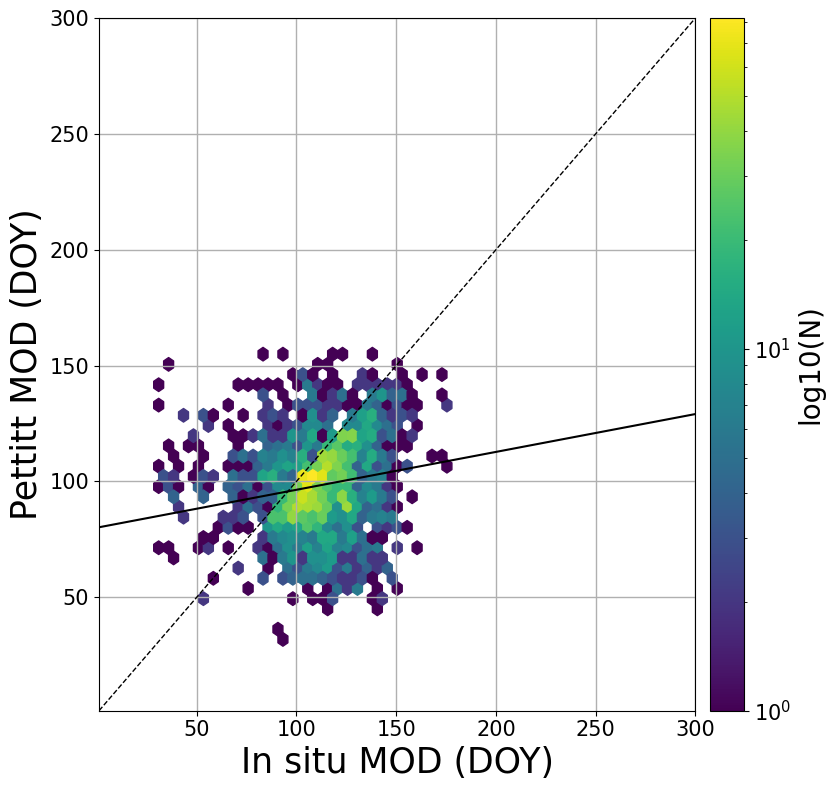

Saved MOD density


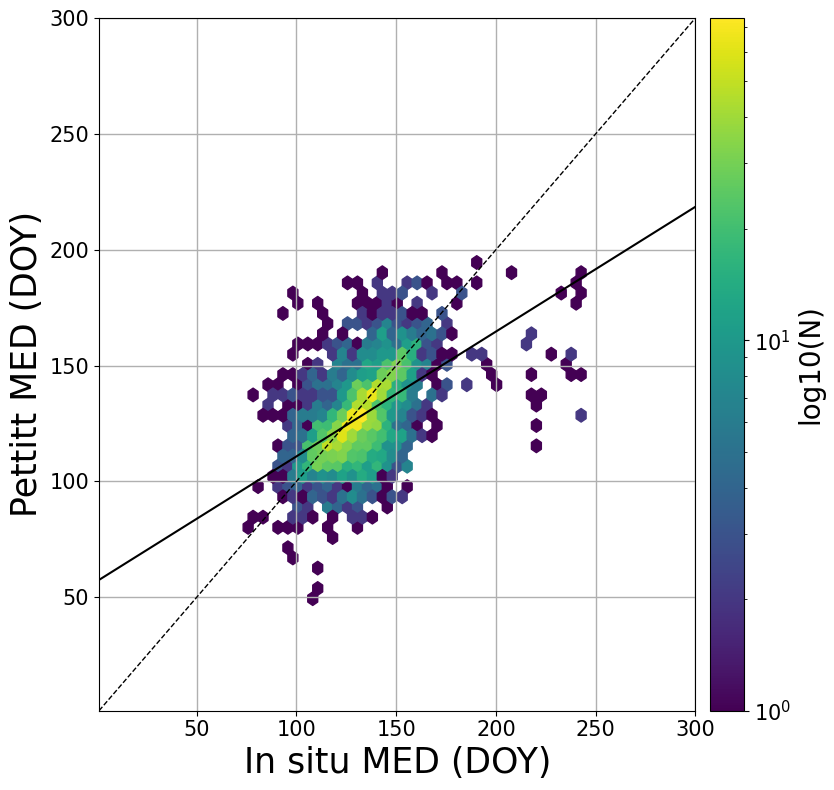

Saved MED density


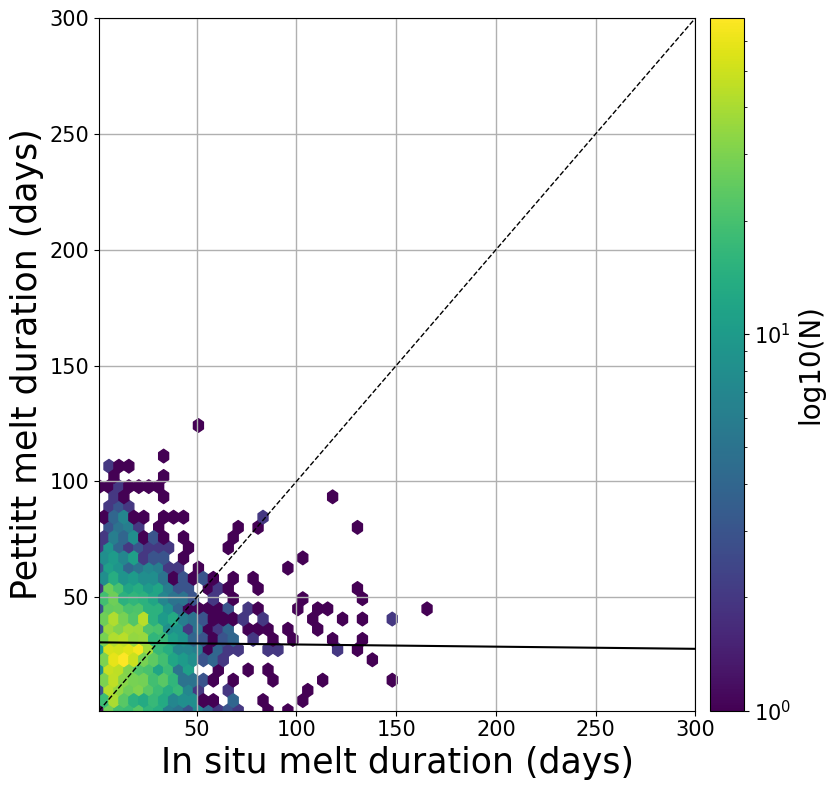

Saved duration density


In [7]:
out_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison"
os.makedirs(out_dir, exist_ok=True)

# 1. MOD (Pettitt vs In situ)
fig1, ax1 = plot_density_3d_vs_3d_clusters012(
    In_situ_MOD, Pettitt_MOD, mask_case2,
    TB_cluster,
    include_clusters=(0,1,2),
    min_n=1,
    gridsize=60,
    cmap="viridis",
    bins="log",
    extent=(1, 300, 1, 300),
    x_label="In situ MOD (DOY)",
    y_label="Pettitt MOD (DOY)",
)

fig1.savefig(
    os.path.join(out_dir, "Insitu_Pettitt_MOD_clusters012.png"),
    dpi=300, bbox_inches="tight", pad_inches=0.07
)
print("Saved MOD density")


# 2. MED (Pettitt vs In situ)
fig2, ax2 = plot_density_3d_vs_3d_clusters012(
    In_situ_MED, Pettitt_MED, mask_case2,
    TB_cluster,
    include_clusters=(0,1,2),
    min_n=1,
    gridsize=60,
    cmap="viridis",
    bins="log",
    extent=(1, 300, 1, 300),
    x_label="In situ MED (DOY)",
    y_label="Pettitt MED (DOY)",
)

fig2.savefig(
    os.path.join(out_dir, "Insitu_Pettitt_MED_clusters012.png"),
    dpi=300, bbox_inches="tight", pad_inches=0.07
)
print("Saved MED density")


# 3. Duration (Pettitt vs In situ)
fig3, ax3 = plot_density_3d_vs_3d_clusters012(
    Insitu_duration, Pettitt_duration, mask_case2,
    TB_cluster,
    include_clusters=(0,1,2),
    min_n=1,
    gridsize=60,
    cmap="viridis",
    bins="log",
    extent=(1, 300, 1, 300),
    x_label="In situ melt duration (days)",
    y_label="Pettitt melt duration (days)",
)

fig3.savefig(
    os.path.join(out_dir, "Insitu_Pettitt_Duration_clusters012.png"),
    dpi=300, bbox_inches="tight", pad_inches=0.07
)
print("Saved duration density")




## 2. Density-Based Comparison with ERA5-Land-Derived Melt Dates

This section presents a 35-year density-based comparison between Pettitt-derived melt dates and those derived from ERA5-Land variables (T_air and SWE)

### Load and open the Pettitt, ERA5-Land data

In [8]:
Pettitt_MOD_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/MOD_MED/MOD_pettitt_250window_MA5_meanstd_1988_2022.nc'
Pettitt_MED_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/MOD_MED/MED_pettitt_250window_MA5_meanstd_1988_2022.nc'
ERA5_MOD_filepath = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/ERA5_Land/ERA5_MOD_1988_2022_north60.nc'
ERA5_MED_filepath = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/ERA5_Land/ERA5_MED_1988_2022_north60.nc'

with nc.Dataset(Pettitt_MOD_path) as ds_Pettitt_MOD:
    lat_vals = ds_Pettitt_MOD.variables['lat'][:]
    lon_vals = ds_Pettitt_MOD.variables['lon'][:]
    Pettitt_MOD  = ds_Pettitt_MOD.variables['MOD_doy'][:]  

with nc.Dataset(Pettitt_MED_path) as ds_Pettitt_MED:
    lat_vals = ds_Pettitt_MED.variables['lat'][:]
    lon_vals = ds_Pettitt_MED.variables['lon'][:]
    Pettitt_MED  = ds_Pettitt_MED.variables['MED_doy'][:] 

with nc.Dataset(ERA5_MOD_filepath) as ds_ERA5_MOD:
    lat_vals = ds_ERA5_MOD.variables['lat'][:]
    lon_vals = ds_ERA5_MOD.variables['lon'][:]
    ERA5_MOD  = ds_ERA5_MOD.variables['MOD_DOY'][:]   # (120, 1440, 35)

with nc.Dataset(ERA5_MED_filepath) as ds_ERA5_MED:
    lat_vals = ds_ERA5_MED.variables['lat'][:]
    lon_vals = ds_ERA5_MED.variables['lon'][:]
    ERA5_MED  = ds_ERA5_MED.variables['MED_DOY'][:]   # (120, 1440, 35)


### Mask out pixels where MOD occurs outside the main melt season

To ensure physical consistency and to avoid capturing snow accumulation events during autumn, MOD values exceeding DOY 250 were excluded. In addition, MOD values earlier than DOY 30 were removed for both Pettitt-derived and ERA5-Land-derived estimates.

In [9]:
mask012 = np.isin(TB_cluster, [0, 1, 2])
mask_ERA5_MOD_250 = np.where((ERA5_MOD < 250) & (ERA5_MOD > 30), ERA5_MOD, np.nan)

# Exclude cases where the Pettitt-derived MOD occurs earlier than DOY 30
mask_Pettitt_MOD_250 = np.where((Pettitt_MOD < 250) & (Pettitt_MOD > 30), Pettitt_MOD, np.nan) 

mask_case2_ERA5 = mask012[:,:,None] & np.isfinite(mask_ERA5_MOD_250) & np.isfinite(mask_Pettitt_MOD_250) & np.isfinite(ERA5_MED) & np.isfinite(Pettitt_MED) & (ERA5_MOD < ERA5_MED)

print("Mask_case2 shape:", mask_case2_ERA5.shape)            
print("Total valid count:", np.sum(mask_case2_ERA5))    


Mask_case2 shape: (120, 1440, 35)
Total valid count: 1288118


### Table 2. Compute statistics using all valid pixel–year pairs (flattened across space and time)

In [10]:
clusters = [0,1,2]
rows = []

# Duration
ERA5_duration = ERA5_MED - ERA5_MOD
Pettitt_duration = Pettitt_MED - Pettitt_MOD

for cid in clusters + ["all012"]:

    if cid == "all012":
        mask_cluster = mask012[:,:,None]
        cname = "All (0–2)"
    else:
        mask_cluster = (TB_cluster == cid)[:,:,None]
        cname = f"Cluster {cid}"

    mask = mask_case2_ERA5 & mask_cluster

    for var, Xp, Xi in [
        ("MOD", Pettitt_MOD, ERA5_MOD),
        ("MED", Pettitt_MED, ERA5_MED),
        ("Duration", Pettitt_duration, ERA5_duration)
    ]:

        diff = (Xp - Xi)[mask]

        if diff.size < 10:
            continue

        rows.append(dict(
            Cluster=cname,
            Variable=var,
            N=len(diff),
            Bias=np.nanmean(diff).round(2),
            MedianBias=np.nanmedian(diff).round(2),
            MAE=np.nanmean(np.abs(diff)).round(2),
            RMSE=np.sqrt(np.nanmean(diff**2)).round(2),
            r=spearmanr(Xp[mask], Xi[mask])[0].round(2),
            P05=np.nanpercentile(diff,5).round(2),
            P95=np.nanpercentile(diff,95).round(2)
        ))

df_stats = pd.DataFrame(rows)
print("Statistics for all valid pixel-year pairs for Pettitt vs ERA5-Land:")
display(df_stats.round(2))

Statistics for all valid pixel-year pairs for Pettitt vs ERA5-Land:


,Cluster,Variable,N,Bias,MedianBias,MAE,RMSE,r,P05,P95
0,Cluster 0,MOD,447502,-25.660000,-23.0,26.840000,33.07,0.27,-65.000000,-1.0
1,Cluster 0,MED,447502,-43.230000,-38.0,43.250000,48.51,0.57,-91.000000,-19.0
2,Cluster 0,Duration,447502,-17.570000,-17.0,26.750000,34.35,-0.07,-69.000000,29.0
3,Cluster 1,MOD,369872,-37.779999,-33.0,37.830002,44.74,0.18,-86.000000,-7.0
4,Cluster 1,MED,369872,-29.330000,-26.0,31.290001,38.31,0.34,-74.000000,9.0
5,Cluster 1,Duration,369872,8.450000,9.0,27.610001,34.74,-0.00,-48.000000,64.0
6,Cluster 2,MOD,470744,-45.169998,-42.0,45.180000,50.22,0.14,-87.000000,-14.0
7,Cluster 2,MED,470744,-46.849998,-41.0,46.880001,53.21,0.38,-93.000000,-15.0
8,Cluster 2,Duration,470744,-1.680000,0.0,27.120001,34.19,-0.01,-61.849998,54.0
9,All (0–2),MOD,1288118,-36.270000,-33.0,36.700001,43.32,0.38,-81.000000,-4.0


### Compute statistics at the pixel level using multi-year means (time-averaged per pixel)

In [11]:
clusters = [0, 1, 2]
rows = []
min_valid_years = 1  

# Duration
ERA5_duration = ERA5_MED - ERA5_MOD
Pettitt_duration = Pettitt_MED - Pettitt_MOD

for cid in clusters + ["all012"]:

    if cid == "all012":
        mask_cluster_2d = mask012
        cname = "All (0–2)"
    else:
        mask_cluster_2d = (TB_cluster == cid)
        cname = f"Cluster {cid}"

    mask_cluster_3d = mask_cluster_2d[:, :, None]

    for var, Xp, Xi in [
        ("MOD", Pettitt_MOD, ERA5_MOD),
        ("MED", Pettitt_MED, ERA5_MED),
        ("Duration", Pettitt_duration, ERA5_duration)
    ]:

        # Valid pixel-year mask
        valid = mask_case2_ERA5 & mask_cluster_3d & np.isfinite(Xp) & np.isfinite(Xi)

        # Number of valid years per pixel
        valid_count = np.sum(valid, axis=2)

        # 35-year mean per pixel
        diff_mean = np.where(
            valid_count >= min_valid_years,
            np.nanmean(np.where(valid, Xp - Xi, np.nan), axis=2),
            np.nan
        )

        xp_mean = np.where(
            valid_count >= min_valid_years,
            np.nanmean(np.where(valid, Xp, np.nan), axis=2),
            np.nan
        )

        xi_mean = np.where(
            valid_count >= min_valid_years,
            np.nanmean(np.where(valid, Xi, np.nan), axis=2),
            np.nan
        )

        # Final valid pixels
        valid_pixel = np.isfinite(diff_mean) & np.isfinite(xp_mean) & np.isfinite(xi_mean)

        diff_pixel = diff_mean[valid_pixel]
        xp_pixel = xp_mean[valid_pixel]
        xi_pixel = xi_mean[valid_pixel]

        if len(diff_pixel) < 3:
            continue

        r_val, p_val = spearmanr(xp_pixel, xi_pixel)
        if p_val < 0.01:
            r_str = f"{r_val:.2f}**"
        elif p_val < 0.05:
            r_str = f"{r_val:.2f}*"
        else:
            r_str = f"{r_val:.2f}"

        rows.append({
            "Cluster": cname,
            "Variable": var,
            "N": len(diff_pixel),  # Number of pixels
            "Bias": round(np.nanmean(diff_pixel), 2),
            "MAE": round(np.nanmean(np.abs(diff_pixel)), 2),
            "RMSE": round(np.sqrt(np.nanmean(diff_pixel**2)), 2),
            "r_s": r_str,
            "Min": round(np.nanmin(diff_pixel), 2),
            "Max": round(np.nanmax(diff_pixel), 2),
        })

df_stats = pd.DataFrame(rows)
print("Statistics for time-averaged per pixel for Pettitt vs ERA5-Land:")
display(df_stats.round(2))

Statistics for time-averaged per pixel for Pettitt vs ERA5-Land:


,Cluster,Variable,N,Bias,MAE,RMSE,r_s,Min,Max
0,Cluster 0,MOD,13070,-25.760000,25.940001,29.340000,0.27**,-75.459999,40.110001
1,Cluster 0,MED,13070,-43.220001,43.220001,44.480000,0.78**,-101.330002,-7.000000
2,Cluster 0,Duration,13070,-17.459999,20.090000,23.709999,-0.05**,-86.099998,68.000000
3,Cluster 1,MOD,11303,-38.560001,38.560001,40.990002,0.30**,-82.309998,-6.260000
4,Cluster 1,MED,11303,-29.299999,29.420000,31.780001,0.48**,-70.599998,16.230000
5,Cluster 1,Duration,11303,9.250000,15.730000,19.070000,-0.08**,-52.689999,54.430000
6,Cluster 2,MOD,13690,-45.099998,45.099998,46.950001,0.25**,-85.169998,-11.170000
7,Cluster 2,MED,13690,-46.980000,46.980000,48.060001,0.69**,-80.900002,2.260000
8,Cluster 2,Duration,13690,-1.880000,13.710000,16.860001,-0.07**,-60.520000,55.540001
9,All (0–2),MOD,38063,-36.520000,36.580002,39.840000,0.58**,-85.169998,40.110001


### Figure 4(a-c). DensityPlot for all valid pixel-year pairs

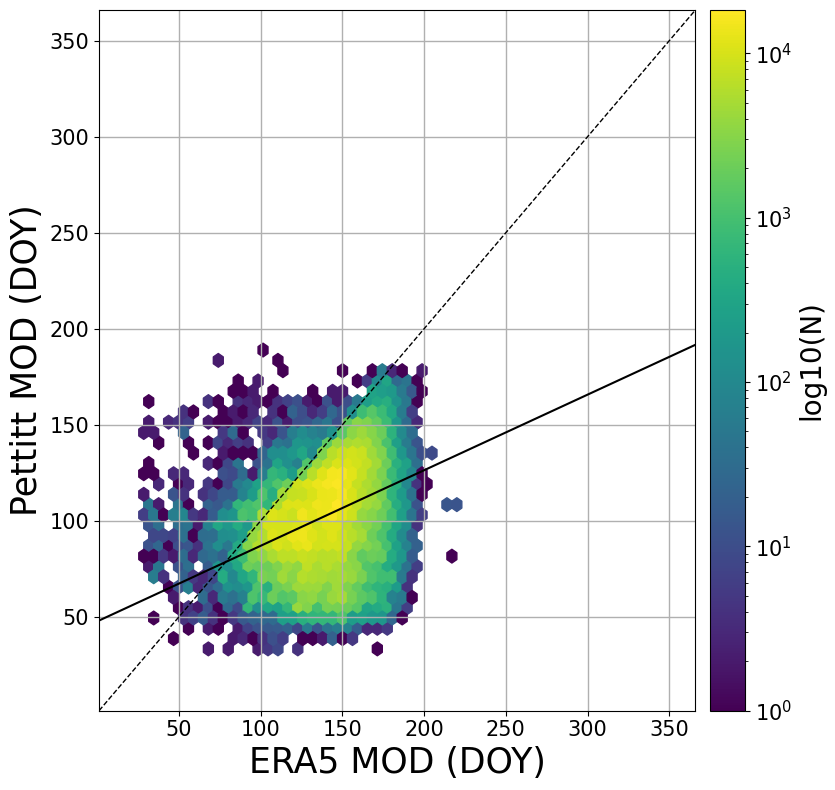

Saved MOD density


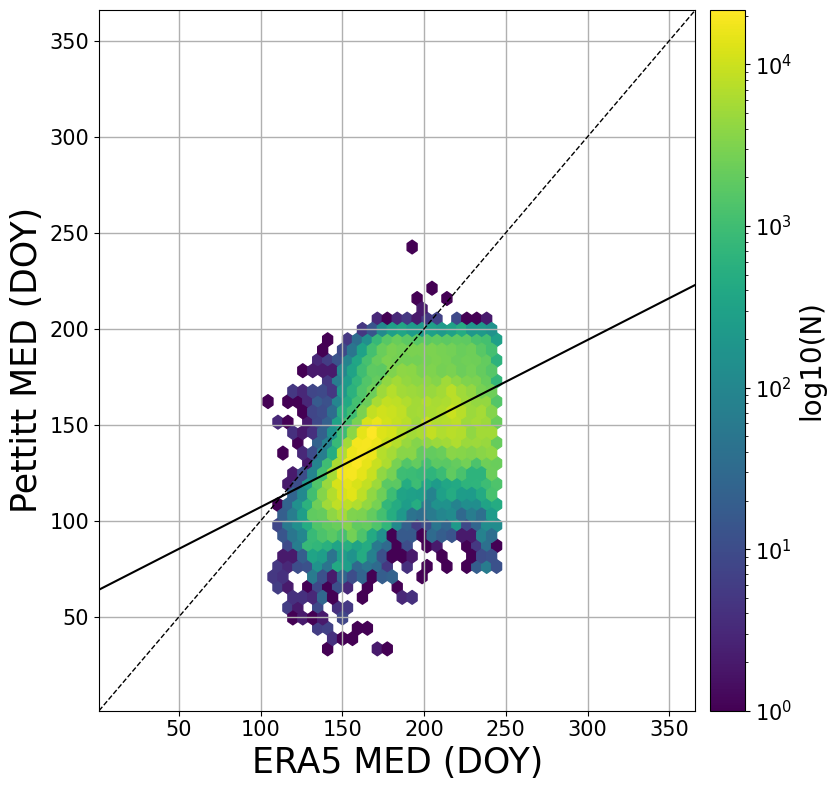

Saved MED density


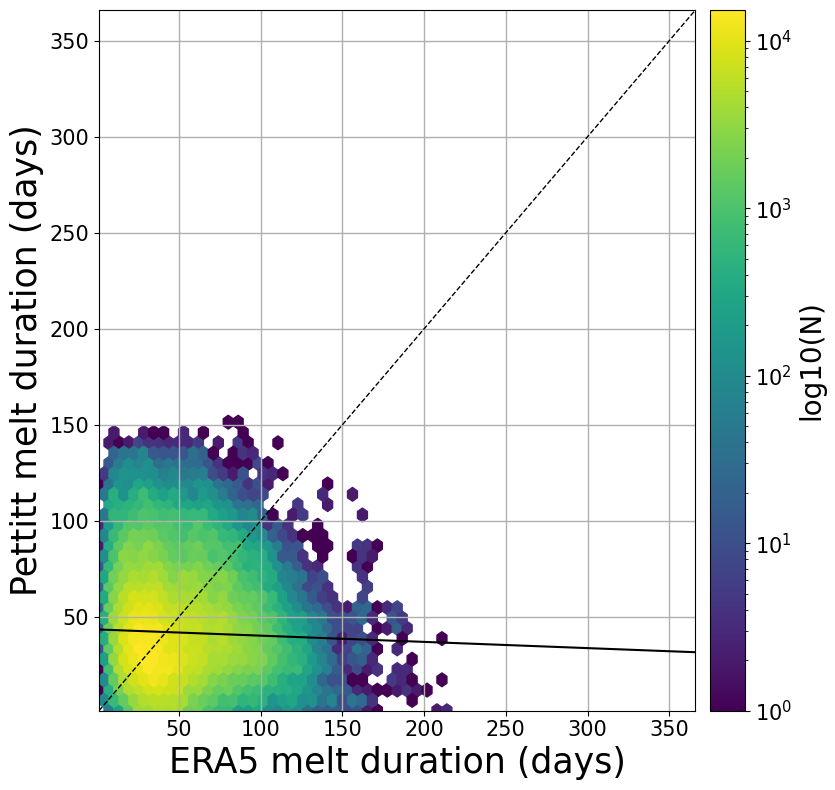

Saved duration density


In [12]:
ERA5_duration = ERA5_MED - ERA5_MOD
Pettitt_duration = Pettitt_MED - Pettitt_MOD

# 1. MOD (ERA5 vs Pettitt)
fig1, ax1 = plot_density_3d_vs_3d_clusters012(
    ERA5_MOD, Pettitt_MOD, mask_case2_ERA5,
    TB_cluster,
    include_clusters=(0,1,2),
    min_n=1,
    gridsize=60,
    cmap="viridis",
    bins="log",
    extent=(1, 366, 1, 366),
    x_label="ERA5 MOD (DOY)",
    y_label="Pettitt MOD (DOY)",
)

fig1.savefig(
    os.path.join(out_dir, "Scatterplot_intercomparison_ERA5_MOD.png"),
    dpi=300, bbox_inches="tight", pad_inches=0.05
)
print("Saved MOD density")


# 2. MED (ERA5 vs Pettitt)
fig2, ax2 = plot_density_3d_vs_3d_clusters012(
    ERA5_MED, Pettitt_MED, mask_case2_ERA5,
    TB_cluster,
    include_clusters=(0,1,2),
    min_n=1,
    gridsize=60,
    cmap="viridis",
    bins="log",
    extent=(1, 366, 1, 366),
    x_label="ERA5 MED (DOY)",
    y_label="Pettitt MED (DOY)",
)

fig2.savefig(
    os.path.join(out_dir, "Scatterplot_intercomparison_ERA5_MED.png"),
    dpi=300, bbox_inches="tight", pad_inches=0.05
)
print("Saved MED density")


# 3. Duration (ERA5 vs Pettitt)
fig3, ax3 = plot_density_3d_vs_3d_clusters012(
    ERA5_duration, Pettitt_duration, mask_case2_ERA5,
    TB_cluster,
    include_clusters=(0,1,2),
    min_n=1,
    gridsize=60,
    cmap="viridis",
    bins="log",
    extent=(1, 366, 1, 366),
    x_label="ERA5 melt duration (days)",
    y_label="Pettitt melt duration (days)",
)

fig3.savefig(
    os.path.join(out_dir, "Scatterplot_intercomparison_ERA5_Duration.png"),
    dpi=300, bbox_inches="tight", pad_inches=0.05
)
print("Saved duration density")


## 3. Density-Based Comparison with Threshold-Based Melt Dates (Wang et al., 2013)

This section presents a 35-year density-based comparison between Pettitt-derived melt dates and those obtained using the threshold-based approach of Wang et al. (2013), which defines melt timing based on predefined thresholds in brightness temperature differences.

### Load and open the Pettitt, Threshold-based data

In [13]:
Pettitt_MOD_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/MOD_MED/MOD_pettitt_250window_MA5_meanstd_1988_2022.nc'
Pettitt_MED_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/MOD_MED/MED_pettitt_250window_MA5_meanstd_1988_2022.nc'
Threshold_MOD_filepath = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/MOD_MED/Threshold_MOD_by_year.nc'
Threshold_MED_filepath = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/MOD_MED/Threshold_MED_by_year.nc'

with nc.Dataset(Pettitt_MOD_path) as ds_Pettitt_MOD:
    lat_vals = ds_Pettitt_MOD.variables['lat'][:]
    lon_vals = ds_Pettitt_MOD.variables['lon'][:]
    Pettitt_MOD  = ds_Pettitt_MOD.variables['MOD_doy'][:]  

with nc.Dataset(Pettitt_MED_path) as ds_Pettitt_MED:
    lat_vals = ds_Pettitt_MED.variables['lat'][:]
    lon_vals = ds_Pettitt_MED.variables['lon'][:]
    Pettitt_MED  = ds_Pettitt_MED.variables['MED_doy'][:] 

with nc.Dataset(Threshold_MOD_filepath) as ds_Threshold_MOD:
    lat_vals = ds_Threshold_MOD.variables['lat'][:]
    lon_vals = ds_Threshold_MOD.variables['lon'][:]
    Threshold_MOD  = ds_Threshold_MOD.variables['MOD_doy'][:] 

with nc.Dataset(Threshold_MED_filepath) as ds_Threshold_MED:
    lat_vals = ds_Threshold_MED.variables['lat'][:]
    lon_vals = ds_Threshold_MED.variables['lon'][:]
    Threshold_MED  = ds_Threshold_MED.variables['MED_doy'][:] 

### Mask out pixels where MOD occurs outside the main melt season

To ensure physical consistency and to avoid capturing snow accumulation events during autumn, MOD values exceeding DOY 250 were excluded. In addition, MOD values earlier than DOY 30 were removed for both Pettitt-derived and Threshold-derived estimates. In addition, especially for the threshold-based method, an additional constraint was applied to ensure that MOD occurs before MED, as this condition was not always satisfied in the original estimates.

In [14]:
mask012 = np.isin(TB_cluster, [0, 1, 2])
mask_Threshold_MOD_250 = np.where((Threshold_MOD < 250) & (Threshold_MOD > 30), Threshold_MOD, np.nan)

# Exclude cases where the Pettitt-derived MOD occurs earlier than DOY 30
mask_Pettitt_MOD_250 = np.where((Pettitt_MOD < 250) & (Pettitt_MOD > 30), Pettitt_MOD, np.nan) 

mask_case2_Threshold = mask012[:,:,None] & np.isfinite(mask_Threshold_MOD_250) & np.isfinite(mask_Pettitt_MOD_250) & np.isfinite(Threshold_MED) & np.isfinite(Pettitt_MED) & (Threshold_MOD < Threshold_MED)

print("Mask_case2 shape:", mask_case2_Threshold.shape)            
print("Total valid count:", np.sum(mask_case2_Threshold))    


Mask_case2 shape: (120, 1440, 35)
Total valid count: 192674


### Table 2. Compute statistics using all valid pixel–year pairs (flattened across space and time)

In [15]:
clusters = [0,1,2]
rows = []

# Duration
Threshold_duration = Threshold_MED - Threshold_MOD
Pettitt_duration = Pettitt_MED - Pettitt_MOD

for cid in clusters + ["all012"]:

    if cid == "all012":
        mask_cluster = mask012[:,:,None]
        cname = "All (0–2)"
    else:
        mask_cluster = (TB_cluster == cid)[:,:,None]
        cname = f"Cluster {cid}"

    mask = mask_case2_Threshold & mask_cluster

    for var, Xp, Xi in [
        ("MOD", Pettitt_MOD, Threshold_MOD),
        ("MED", Pettitt_MED, Threshold_MED),
        ("Duration", Pettitt_duration, Threshold_duration)
    ]:

        diff = (Xp - Xi)[mask]

        if diff.size < 10:
            continue

        rows.append(dict(
            Cluster=cname,
            Variable=var,
            N=len(diff),
            Bias=np.nanmean(diff).round(2),
            MedianBias=np.nanmedian(diff).round(2),
            MAE=np.nanmean(np.abs(diff)).round(2),
            RMSE=np.sqrt(np.nanmean(diff**2)).round(2),
            r=spearmanr(Xp[mask], Xi[mask])[0].round(2),
            P05=np.nanpercentile(diff,5).round(2),
            P95=np.nanpercentile(diff,95).round(2)
        ))

df_stats = pd.DataFrame(rows)
print("Statistics for all valid pixel-year pairs for Pettitt vs Threshold:")
display(df_stats.round(2))

Statistics for all valid pixel-year pairs for Pettitt vs Threshold:


,Cluster,Variable,N,Bias,MedianBias,MAE,RMSE,r,P05,P95
0,Cluster 0,MOD,82224,-1.030000,-4.0,24.209999,31.18,0.18,-52.0,53.0
1,Cluster 0,MED,82224,2.610000,4.0,11.430000,17.78,0.77,-25.0,24.0
2,Cluster 0,Duration,82224,3.640000,5.0,22.840000,30.10,-0.07,-49.0,49.0
3,Cluster 1,MOD,60533,-22.620001,-21.0,29.240000,36.39,0.11,-73.0,20.0
4,Cluster 1,MED,60533,7.320000,7.0,14.140000,19.41,0.62,-22.0,32.0
5,Cluster 1,Duration,60533,29.940001,30.0,34.910000,42.63,-0.13,-17.0,81.0
6,Cluster 2,MOD,49917,-31.650000,-31.0,33.860001,40.27,0.09,-76.0,9.0
7,Cluster 2,MED,49917,1.640000,3.0,8.480000,13.73,0.73,-22.0,15.0
8,Cluster 2,Duration,49917,33.279999,33.0,35.959999,42.09,0.07,-7.0,78.0
9,All (0–2),MOD,192674,-15.750000,-16.0,28.290001,35.37,0.25,-69.0,36.0


### Compute statistics at the pixel level using multi-year means (time-averaged per pixel)

In [16]:
clusters = [0, 1, 2]
rows = []
min_valid_years = 1  

# Duration
Threshold_duration = Threshold_MED - Threshold_MOD
Pettitt_duration = Pettitt_MED - Pettitt_MOD

for cid in clusters + ["all012"]:

    if cid == "all012":
        mask_cluster_2d = mask012
        cname = "All (0–2)"
    else:
        mask_cluster_2d = (TB_cluster == cid)
        cname = f"Cluster {cid}"

    mask_cluster_3d = mask_cluster_2d[:, :, None]

    # Xp: Pettitt-derived estimates
    # Xi: Threshold-based estimates (comparison dataset)
    for var, Xp, Xi in [
        ("MOD", Pettitt_MOD, Threshold_MOD),
        ("MED", Pettitt_MED, Threshold_MED),
        ("Duration", Pettitt_duration, Threshold_duration)
    ]:

        # Valid pixel-year mask
        valid = mask_case2_Threshold & mask_cluster_3d & np.isfinite(Xp) & np.isfinite(Xi)

        # Number of valid years per pixel
        valid_count = np.sum(valid, axis=2)

        # 35-year mean per pixel
        diff_mean = np.where(
            valid_count >= min_valid_years,
            np.nanmean(np.where(valid, Xp - Xi, np.nan), axis=2),
            np.nan
        )

        xp_mean = np.where(
            valid_count >= min_valid_years,
            np.nanmean(np.where(valid, Xp, np.nan), axis=2),
            np.nan
        )

        xi_mean = np.where(
            valid_count >= min_valid_years,
            np.nanmean(np.where(valid, Xi, np.nan), axis=2),
            np.nan
        )

        # Final valid pixels
        valid_pixel = np.isfinite(diff_mean) & np.isfinite(xp_mean) & np.isfinite(xi_mean)

        diff_pixel = diff_mean[valid_pixel]
        xp_pixel = xp_mean[valid_pixel]
        xi_pixel = xi_mean[valid_pixel]

        if len(diff_pixel) < 3:
            continue

        r_val, p_val = spearmanr(xp_pixel, xi_pixel)
        if p_val < 0.01:
            r_str = f"{r_val:.2f}**"
        elif p_val < 0.05:
            r_str = f"{r_val:.2f}*"
        else:
            r_str = f"{r_val:.2f}"

        rows.append({
            "Cluster": cname,
            "Variable": var,
            "N": len(diff_pixel),  # Number of pixels
            "Bias": round(np.nanmean(diff_pixel), 2),
            "MedianBias": round(np.nanmedian(diff_pixel), 2),
            "MAE": round(np.nanmean(np.abs(diff_pixel)), 2),
            "RMSE": round(np.sqrt(np.nanmean(diff_pixel**2)), 2),
            "r_s": r_str,
            "Min": round(np.nanmin(diff_pixel), 2),
            "Max": round(np.nanmax(diff_pixel), 2),
        })

df_stats = pd.DataFrame(rows)
print("Statistics for time-averaged per pixel for Pettitt vs Threshold:")
display(df_stats.round(2))

Statistics for time-averaged per pixel for Pettitt vs Threshold:


,Cluster,Variable,N,Bias,MedianBias,MAE,RMSE,r_s,Min,Max
0,Cluster 0,MOD,13356,-5.480000,-5.000000,17.889999,22.830000,0.20**,-99.500000,110.000000
1,Cluster 0,MED,13356,2.040000,3.600000,8.710000,12.980000,0.82**,-153.000000,78.000000
2,Cluster 0,Duration,13356,7.520000,7.130000,16.240000,20.889999,-0.14**,-119.889999,99.000000
3,Cluster 1,MOD,11474,-25.320000,-22.670000,26.090000,31.670000,0.22**,-107.000000,39.000000
4,Cluster 1,MED,11474,8.070000,7.610000,11.650000,14.680000,0.65**,-110.000000,44.330002
5,Cluster 1,Duration,11474,33.400002,33.799999,34.189999,39.130001,-0.25**,-76.000000,119.000000
6,Cluster 2,MOD,12346,-31.780001,-30.799999,32.000000,36.119999,0.16**,-107.000000,17.000000
7,Cluster 2,MED,12346,2.110000,3.750000,6.830000,9.920000,0.74**,-111.000000,56.000000
8,Cluster 2,Duration,12346,33.889999,33.599998,34.380001,38.230000,0.09**,-75.000000,108.000000
9,All (0–2),MOD,37176,-20.340000,-20.000000,25.100000,30.500000,0.43**,-107.000000,110.000000


### Figure 4(d-f). DensityPlot for all valid pixel-year pairs

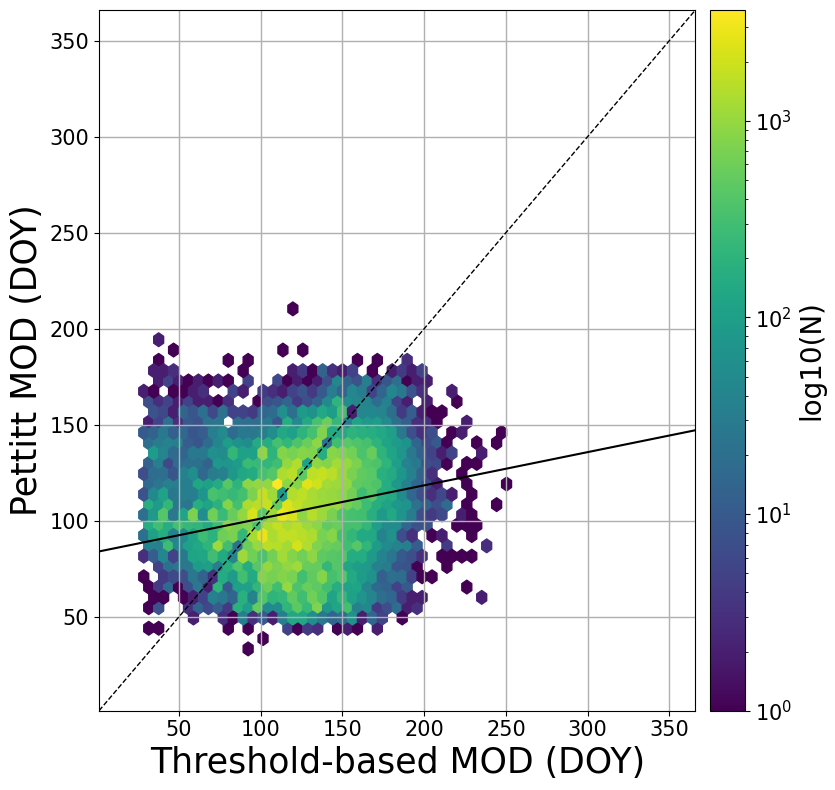

Saved MOD density


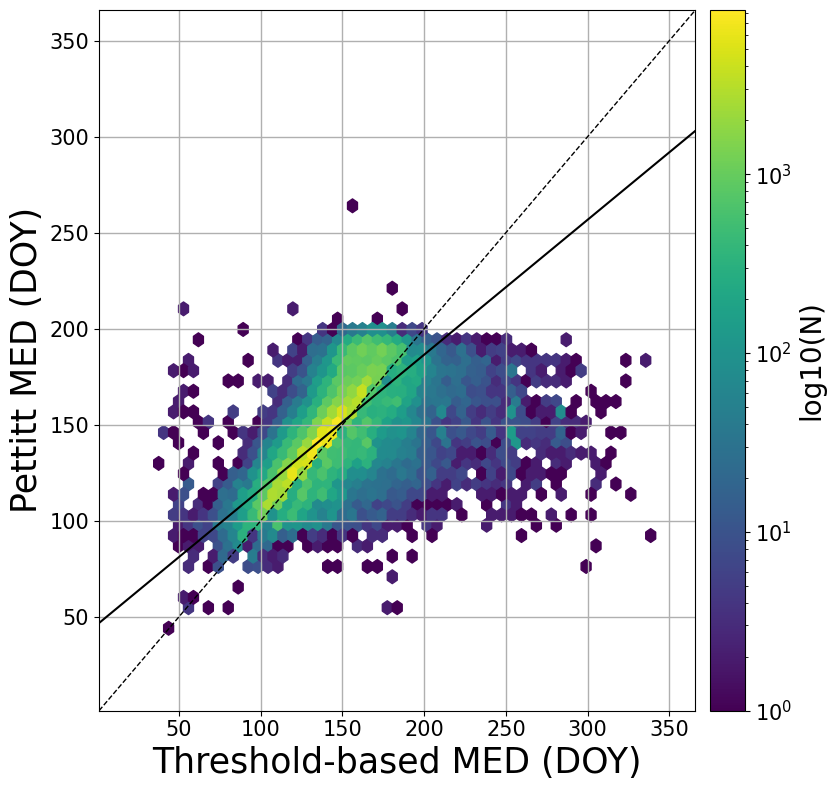

Saved MED density


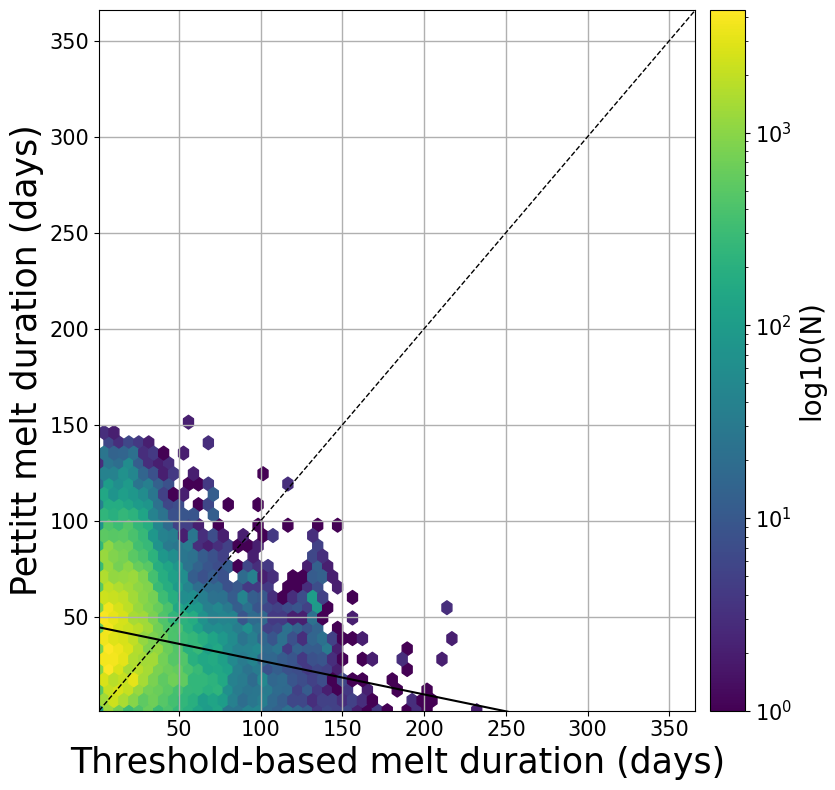

Saved duration density


In [17]:
Threshold_duration = Threshold_MED - Threshold_MOD
Pettitt_duration = Pettitt_MED - Pettitt_MOD
out_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison"

# 1. MOD (Threshold vs Pettitt)
fig1, ax1 = plot_density_3d_vs_3d_clusters012(
    Threshold_MOD, Pettitt_MOD, mask_case2_Threshold,
    TB_cluster,
    include_clusters=(0,1,2),
    min_n=1,
    gridsize=60,
    cmap="viridis",
    bins="log",
    extent=(1, 366, 1, 366),
    x_label="Threshold-based MOD (DOY)",
    y_label="Pettitt MOD (DOY)",
)

fig1.savefig(
    os.path.join(out_dir, "Scatterplot_intercomparison_Wang_MOD.png"),
    dpi=300, bbox_inches="tight", pad_inches=0.05
)
print("Saved MOD density")


# 2. MED (Threshold vs Pettitt)
fig2, ax2 = plot_density_3d_vs_3d_clusters012(
    Threshold_MED, Pettitt_MED, mask_case2_Threshold,
    TB_cluster,
    include_clusters=(0,1,2),
    min_n=1,
    gridsize=60,
    cmap="viridis",
    bins="log",
    extent=(1, 366, 1, 366),
    x_label="Threshold-based MED (DOY)",
    y_label="Pettitt MED (DOY)",
)

fig2.savefig(
    os.path.join(out_dir, "Scatterplot_intercomparison_Wang_MED.png"),
    dpi=300, bbox_inches="tight", pad_inches=0.05
)
print("Saved MED density")


# 3. Duration (Threshold vs Pettitt)
fig3, ax3 = plot_density_3d_vs_3d_clusters012(
    Threshold_duration, Pettitt_duration, mask_case2_Threshold,
    TB_cluster,
    include_clusters=(0,1,2),
    min_n=1,
    gridsize=60,
    cmap="viridis",
    bins="log",
    extent=(1, 366, 1, 366),
    x_label="Threshold-based melt duration (days)",
    y_label="Pettitt melt duration (days)",
)

fig3.savefig(
    os.path.join(out_dir, "Scatterplot_intercomparison_Wang_Duration.png"),
    dpi=300, bbox_inches="tight", pad_inches=0.05
)
print("Saved duration density")
